In [2]:
# ЯЧЕЙКА 1: Импорты и гиперпараметры
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import os

from olimp.dataset.olimp import olimp
from olimp.dataset import read_img_path

/home/user/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
IMG_SIZE    = 512
SIGMA       = 0.01       # уменьшен с 0.02 для меньшего шума
TRAIN_RATIO = 0.85
BATCH_SIZE  = 8          # увеличено (при 2 GPU → 4 на карту)
NUM_EPOCHS  = 60         # увеличено
LR          = 1e-4       # немного снижено для стабильности
DEVICE      = torch.device("cuda:1")
LAMBDA_K    = 2.5        # повышен вес supervised‑лосса для чёткой маски
SAVE_PATH   = "best_model12.1.pt"

In [13]:
# ЯЧЕЙКА 2: Загрузка путей к изображениям

CATEGORIES = [
    'abstracts and textures', 'abstracts and textures/abstract art',
    'abstracts and textures/backgrounds and patterns',
    'abstracts and textures/colorful abstracts',
    'abstracts and textures/geometric shapes',
    'abstracts and textures/neon abstracts', 'abstracts and textures/textures',
    'animals', 'animals/birds', 'animals/farm animals',
    'animals/insects and spiders', 'animals/marine life', 'animals/pets',
    'animals/wild animals', 'art and culture',
    'art and culture/cartoon and comics',
    'art and culture/crafts and handicrafts',
    'art and culture/dance and theater performances',
    'art and culture/music concerts and instruments',
    'art and culture/painting and frescoes',
    'art and culture/sculpture and bas-reliefs', 'food and drinks',
    'food and drinks/desserts and bakery', 'food and drinks/dishes',
    'food and drinks/drinks',
    'food and drinks/food products on store shelves',
    'food and drinks/fruits and vegetables', 'food and drinks/street food',
    'interiors', 'interiors/gyms and pools', 'interiors/living spaces',
    'interiors/museums and galleries', 'interiors/offices',
    'interiors/restaurants and cafes',
    'interiors/shopping centers and stores', 'nature', 'nature/beaches',
    'nature/deserts', 'nature/fields and meadows', 'nature/forest',
    'nature/mountains', 'nature/water bodies', 'objects and items',
    'objects and items/books and stationery',
    'objects and items/clothing and accessories',
    'objects and items/electronics and gadgets',
    'objects and items/furniture and decor',
    'objects and items/tools and equipment',
    'objects and items/toys and games', 'portraits and people',
    'portraits and people/athletes and dancers',
    'portraits and people/crowds and demonstrations',
    'portraits and people/group photos',
    'portraits and people/individual portraits',
    'portraits and people/models on runway',
    'portraits and people/workers in their workplaces',
    'sports and active leisure',
    'sports and active leisure/cycling and rollerblading',
    'sports and active leisure/extreme sports',
    'sports and active leisure/individual sports',
    'sports and active leisure/martial arts',
    'sports and active leisure/team sports',
    'sports and active leisure/tourism and hikes', 'text and pictogram',
    'text and pictogram/billboard text', 'text and pictogram/blueprints',
    'text and pictogram/caricatures and pencil drawing',
    'text and pictogram/text documents', 'text and pictogram/traffic signs',
    'urban scenes', 'urban scenes/architecture',
    'urban scenes/city at night', 'urban scenes/graffiti and street art',
    'urban scenes/parks and squares', 'urban scenes/streets and avenues',
    'urban scenes/transport',
]

all_paths = []
for cat in CATEGORIES:
    try:
        ds    = olimp(categories={cat})
        paths = ds[cat]
        all_paths.extend(paths)
    except Exception as e:
        print(f"  {cat}: пропущено ({e})")

rng = np.random.default_rng(42)
rng.shuffle(all_paths)
all_paths = all_paths[:1500]
print(f"\nИтого загружено: {len(all_paths)} изображений")

n_train     = int(TRAIN_RATIO * len(all_paths))
train_paths = all_paths[:n_train]
val_paths   = all_paths[n_train:]
print(f"Train: {len(train_paths)} | Val: {len(val_paths)}")

/home/user/.local/lib/python3.10/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')


Итого загружено: 1500 изображений
Train: 1275 | Val: 225


In [4]:
# ЯЧЕЙКА 3: Генерация конфигураций масок K (расширенная)
_cfg_rng = np.random.default_rng(0)


# Горизонтальные – 1500 штук (было 1000)
stripe_h_configs = [
    {"type": "h", "width": float(w)}
    for w in _cfg_rng.uniform(4, 200, 1500)   # шире диапазон, больше конфигураций
]

# Вертикальные полосы
stripe_v_configs = [
    {"type": "v", "width": float(w)}
    for w in _cfg_rng.uniform(2, 150, 1500)
]

# Диагональные прямоугольные – 2000 штук
stripe_d_configs = [
    {"type": "d", "width": float(w), "angle": float(a)}
    for w, a in zip(
        _cfg_rng.uniform(6, 180, 2000),
        _cfg_rng.uniform(0, 180, 2000)
    )
]

# Синусоидальные – оставляем 1000 (можно даже меньше)
sin_configs = [
    {"type": "s", "freq": float(f), "angle": float(a), "phase": float(p)}
    for f, a, p in zip(
        _cfg_rng.uniform(1/120, 1/8, 1000),
        _cfg_rng.uniform(0, 180, 1000),
        _cfg_rng.uniform(0, 2*np.pi, 1000),
    )
]

ALL_CONFIGS = stripe_h_configs + stripe_v_configs + stripe_d_configs + sin_configs
print(f"Конфигураций K: {len(ALL_CONFIGS)}")

def make_mask(h: int, w: int, config: dict) -> np.ndarray:
    """K ∈ [0,1] — маска полос."""
    if config["type"] == "h":
        sw = max(1, int(config["width"]))
        K  = ((np.arange(h) // sw) % 2).astype(np.float32)
        return K[:, None] * np.ones((1, w), dtype=np.float32)
    elif config["type"] == "v":
        sw = max(1, int(config["width"]))
        K  = ((np.arange(w) // sw) % 2).astype(np.float32)
        return K[None, :] * np.ones((h, 1), dtype=np.float32)
    elif config["type"] == "d":
        # Наклонные полосы: вращаем координаты
        sw = max(1, int(config["width"]))
        angle = np.radians(config["angle"])
        xs = np.arange(w, dtype=np.float32)[None, :]
        ys = np.arange(h, dtype=np.float32)[:, None]
        # Проекция на направление, перпендикулярное полосам
        dist = xs * np.cos(angle) + ys * np.sin(angle)
        K = ((dist // sw) % 2).astype(np.float32)
        return K
    # синус
    freq  = config["freq"]
    angle = np.radians(config["angle"])
    phase = config["phase"]
    a = 2 * np.pi * freq * np.cos(angle)
    b = 2 * np.pi * freq * np.sin(angle)
    xs = np.arange(w, dtype=np.float32)[None, :]
    ys = np.arange(h, dtype=np.float32)[:, None]
    return ((np.sin(a * xs + b * ys + phase) + 1) / 2).astype(np.float32)

Конфигураций K: 6000


In [5]:

# ------------------- Вспомогательные функции -------------------
def load_rg(img_path) -> np.ndarray:
    """Загружает изображение → float32 [H,W,2] каналы R,G."""
    img = read_img_path(img_path)
    img = np.array(img, dtype=np.float32) / 255.0
    img = np.transpose(img, (1, 2, 0))          # CHW → HWC
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    if img.ndim == 2:
        img = np.stack([img, img, img], axis=-1)
    elif img.shape[2] == 1:
        img = np.concatenate([img, img, img], axis=-1)
    return img[:, :, :2].astype(np.float32)     # только R, G

def make_mask(h: int, w: int, config: dict) -> np.ndarray:
    """K ∈ [0,1] — маска полос."""
    if config["type"] == "h":
        sw = max(1, int(config["width"]))
        K  = ((np.arange(h) // sw) % 2).astype(np.float32)
        return K[:, None] * np.ones((1, w), dtype=np.float32)
    elif config["type"] == "v":
        sw = max(1, int(config["width"]))
        K  = ((np.arange(w) // sw) % 2).astype(np.float32)
        return K[None, :] * np.ones((h, 1), dtype=np.float32)
    elif config["type"] == "d":
        sw = max(1, int(config["width"]))
        angle = np.radians(config["angle"])
        xs = np.arange(w, dtype=np.float32)[None, :]
        ys = np.arange(h, dtype=np.float32)[:, None]
        dist = xs * np.cos(angle) + ys * np.sin(angle)
        return ((dist // sw) % 2).astype(np.float32)
    # синусоидальный паттерн
    freq  = config["freq"]
    angle = np.radians(config["angle"])
    phase = config["phase"]
    a = 2 * np.pi * freq * np.cos(angle)
    b = 2 * np.pi * freq * np.sin(angle)
    xs = np.arange(w, dtype=np.float32)[None, :]
    ys = np.arange(h, dtype=np.float32)[:, None]
    return ((np.sin(a * xs + b * ys + phase) + 1) / 2).astype(np.float32)

def make_measurement(rg: np.ndarray, K: np.ndarray) -> np.ndarray:
    """P = K·R^0.7 + (1-K)·G² + N(0,σ), зажатое в [0,1]."""
    R, G = rg[:, :, 0], rg[:, :, 1]
    P    = K * R ** 0.7 + (1 - K) * G ** 2
    return np.clip(P + np.random.normal(0, SIGMA, P.shape).astype(np.float32), 0, 1)

In [11]:
# ЯЧЕЙКА 4: Dataset

class StripeDataset(Dataset):
    """
    Возвращает словарь:
      P   – измерение [1, H, W]  (вход сети)
      R   – канал R   [1, H, W]  (нужен для лосса)
      G   – канал G   [1, H, W]  (нужен для лосса)
      K   – GT маска  [1, H, W]  (нужен для supervised-лосса)
    """
    def __init__(self, paths, configs, augment: bool = False):
        self.paths   = paths
        self.configs = configs
        self.augment = augment
        self._cfg_rng = np.random.default_rng(1337)

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        rg  = load_rg(self.paths[idx])           # [H,W,2]
        H, W = rg.shape[:2]

        cfg = self.configs[self._cfg_rng.integers(len(self.configs))]
        K   = make_mask(H, W, cfg)               # [H,W]
        P   = make_measurement(rg, K)            # [H,W]

        if self.augment:
            # случайные флипы (как было)
            if self._cfg_rng.random() > 0.5:
                rg = rg[:, ::-1, :].copy()
                K  = K[:, ::-1].copy()
                P  = P[:, ::-1].copy()
            if self._cfg_rng.random() > 0.5:
                rg = rg[::-1, :, :].copy()
                K  = K[::-1, :].copy()
                P  = P[::-1, :].copy()

            # поворот на 90° (с вероятностью 0.5)
            if self._cfg_rng.random() > 0.5:
                k = self._cfg_rng.integers(0, 4)
                if k:
                    rg = np.rot90(rg, k, axes=(0,1)).copy()
                    K  = np.rot90(K, k).copy()
                    P  = np.rot90(P, k).copy()

            # небольшое масштабирование (0.9–1.1) с последующим crop/pad до 512
            if self._cfg_rng.random() > 0.7:
                scale = self._cfg_rng.uniform(0.9, 1.1)
                new_h, new_w = int(H*scale), int(W*scale)
                rg_resized = cv2.resize(rg, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
                K_resized  = cv2.resize(K,  (new_w, new_h), interpolation=cv2.INTER_NEAREST)
                P_resized  = cv2.resize(P,  (new_w, new_h), interpolation=cv2.INTER_LINEAR)
                if scale < 1.0:
                    # pad
                    pad_h = (H - new_h)//2
                    pad_w = (W - new_w)//2
                    rg = np.pad(rg_resized, ((pad_h, H-new_h-pad_h), (pad_w, W-new_w-pad_w), (0,0)), mode='reflect')
                    K  = np.pad(K_resized,  ((pad_h, H-new_h-pad_h), (pad_w, W-new_w-pad_w)), mode='constant', constant_values=0)
                    P  = np.pad(P_resized,  ((pad_h, H-new_h-pad_h), (pad_w, W-new_w-pad_w)), mode='reflect')
                else:
                    # crop
                    start_h = (new_h - H)//2
                    start_w = (new_w - W)//2
                    rg = rg_resized[start_h:start_h+H, start_w:start_w+W]
                    K  = K_resized[start_h:start_h+H, start_w:start_w+W]
                    P  = P_resized[start_h:start_h+H, start_w:start_w+W]

            # лёгкие цветовые вариации (только на R и G)
            if self._cfg_rng.random() > 0.5:
                rg[:,:,0] = np.clip(rg[:,:,0] * self._cfg_rng.uniform(0.9, 1.1), 0, 1)
                rg[:,:,1] = np.clip(rg[:,:,1] * self._cfg_rng.uniform(0.9, 1.1), 0, 1)
                # пересчитываем P после изменения rg
                P = make_measurement(rg, K)

        return {
            "P": torch.from_numpy(P[None]),
            "R": torch.from_numpy(rg[:,:,0][None]),
            "G": torch.from_numpy(rg[:,:,1][None]),
            "K": torch.from_numpy(K[None]),
        }

In [6]:
# ЯЧЕЙКА 5: Архитектура — UNet с ResNet-блоками (улучшенная версия)

class ResBlock(nn.Module):
    def __init__(self, ch, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(ch),
            nn.GELU(),
            nn.Dropout2d(dropout),          # <-- регуляризация для подавления шума
            nn.Conv2d(ch, ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(ch),
        )
        self.dropout = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        return F.gelu(x + self.dropout(self.net(x)))


class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch, n_res=2, dropout=0.1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
            *[ResBlock(out_ch, dropout) for _ in range(n_res)],
        )
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        x = self.conv(x)
        return self.pool(x), x          # (pooled, skip)


class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, n_res=2, dropout=0.1):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
        # После cat: out_ch (от up) + skip_ch (от энкодера)
        self.conv = nn.Sequential(
            nn.Conv2d(out_ch + skip_ch, out_ch, 3, padding=1, bias=False),
            nn.GroupNorm(min(8, out_ch), out_ch),
            nn.GELU(),
            *[ResBlock(out_ch, dropout) for _ in range(n_res)],
        )

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[2:] != skip.shape[2:]:
            x = F.interpolate(x, size=skip.shape[2:], mode="bilinear",
                              align_corners=False)
        return self.conv(torch.cat([x, skip], dim=1))


class KPredictor(nn.Module):
    def __init__(self, base_ch=32, dropout=0.1):
        super().__init__()
        # Encoder
        self.d1 = DownBlock(1,         base_ch,       dropout=dropout)   # skip → 32 ch
        self.d2 = DownBlock(base_ch,   base_ch * 2,   dropout=dropout)   # skip → 64 ch
        self.d3 = DownBlock(base_ch*2, base_ch * 4,   dropout=dropout)   # skip → 128 ch
        self.d4 = DownBlock(base_ch*4, base_ch * 8,   dropout=dropout)   # skip → 256 ch

        self.bot = nn.Sequential(
            ResBlock(base_ch*8, dropout),
            ResBlock(base_ch*8, dropout)
        )

        # Декодер
        self.u4 = UpBlock(base_ch*8, base_ch*8, base_ch*4, dropout=dropout)
        self.u3 = UpBlock(base_ch*4, base_ch*4, base_ch*2, dropout=dropout)
        self.u2 = UpBlock(base_ch*2, base_ch*2, base_ch,   dropout=dropout)
        self.u1 = UpBlock(base_ch,   base_ch,   base_ch,   dropout=dropout)

        # Голова — без Sigmoid (применяется в forward)
        self.head = nn.Sequential(
            nn.Conv2d(base_ch, base_ch // 2, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(base_ch // 2, 1, 1),
        )

    def forward(self, P):
        x, s1 = self.d1(P)    # s1: 32 ch
        x, s2 = self.d2(x)    # s2: 64 ch
        x, s3 = self.d3(x)    # s3: 128 ch
        x, s4 = self.d4(x)    # s4: 256 ch
        x = self.bot(x)
        x = self.u4(x, s4)    # up(256→128) + skip(256) → conv(384→128)
        x = self.u3(x, s3)    # up(128→64)  + skip(128) → conv(192→64)
        x = self.u2(x, s2)    # up(64→32)   + skip(64)  → conv(96→32)
        x = self.u1(x, s1)    # up(32→32)   + skip(32)  → conv(64→32)
        out = self.head(x)
        return torch.sigmoid(out)   # выход в [0,1]


# Инициализация с учётом multi‑GPU
NUM_GPUS = torch.cuda.device_count()
print(f"Доступно GPU: {NUM_GPUS}")

_base_model = KPredictor(base_ch=32, dropout=0.1)

if NUM_GPUS > 1:
    _base_model = _base_model.to("cuda:0")
    model = nn.DataParallel(_base_model, device_ids=list(range(NUM_GPUS)))
    print(f"Используем {NUM_GPUS} GPU: DataParallel")
else:
    model = _base_model.to(DEVICE)
    print("Используем 1 GPU / CPU")

raw_model = model.module if NUM_GPUS > 1 else model

n_params = sum(p.numel() for p in raw_model.parameters() if p.requires_grad)
print(f"Параметров: {n_params:,}")

# Проверка формы
test_bs = max(2, NUM_GPUS)
with torch.no_grad():
    dummy = torch.zeros(test_bs, 1, IMG_SIZE, IMG_SIZE, device="cuda:0")
    out   = model(dummy)
    print(f"Output shape: {out.shape}")


Доступно GPU: 2
Используем 2 GPU: DataParallel
Параметров: 7,480,577


/home/user/.local/lib/python3.10/site-packages/torch/nn/modules/conv.py:456: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias, self.stride,


Output shape: torch.Size([2, 1, 512, 512])


In [7]:
def dice_loss(pred, target, smooth=1e-5):
    """Soft Dice loss для бинарных масок (значения в [0,1])"""
    pred = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum()
    return 1 - (2. * intersection + smooth) / (union + smooth)

def gradient_loss(pred, target):
    """L1 между градиентами (помогает сохранить чёткие границы)"""
    def sobel(x):
        dx = x[:, :, :, 1:] - x[:, :, :, :-1]
        dy = x[:, :, 1:, :] - x[:, :, :-1, :]
        return dx, dy
    dx_pred, dy_pred = sobel(pred)
    dx_true, dy_true = sobel(target)
    return F.l1_loss(dx_pred, dx_true) + F.l1_loss(dy_pred, dy_true)

def tv_loss(pred):
    """Полная вариация – сглаживает шум внутри полос"""
    dx = pred[:, :, :, 1:] - pred[:, :, :, :-1]
    dy = pred[:, :, 1:, :] - pred[:, :, :-1, :]
    return dx.abs().mean() + dy.abs().mean()

def reconstruction_loss(K_hat, R, G, P):
    dev = K_hat.device
    R = R.to(dev)
    G = G.to(dev)
    P = P.to(dev)
    eps = 1e-6
    R_pow = torch.pow(R.clamp(eps, 1.0), 0.7)
    G_sq = G ** 2
    P_hat = K_hat * R_pow + (1 - K_hat) * G_sq
    return F.mse_loss(P_hat, P), P_hat

def total_loss(K_hat, K_gt, R, G, P, lambda_k: float = LAMBDA_K):
    dev = K_hat.device
    K_gt = K_gt.to(dev)
    R = R.to(dev)
    G = G.to(dev)
    P = P.to(dev)

    l_rec, P_hat = reconstruction_loss(K_hat, R, G, P)

    # Комбинированный лосс для маски
    l_dice   = dice_loss(K_hat, K_gt)
    l_grad   = gradient_loss(K_hat, K_gt)
    l_tv     = tv_loss(K_hat) * 0.01          # лёгкое сглаживание
    l_mse_k  = F.mse_loss(K_hat, K_gt) * 0.1  # небольшая добавка MSE

    l_k = l_dice + l_grad + l_tv + l_mse_k

    return l_rec + lambda_k * l_k, l_rec, l_k, P_hat

In [26]:
# ЯЧЕЙКА 7: DataLoader с корректным batch-размером для multi‑GPU
train_ds = StripeDataset(train_paths, ALL_CONFIGS, augment=True)
val_ds   = StripeDataset(val_paths,   ALL_CONFIGS, augment=False)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=2, pin_memory=True)

# Рассчитываем эффективный размер батча, кратный числу GPU
EFF_BATCH = max(BATCH_SIZE, NUM_GPUS)
if EFF_BATCH % NUM_GPUS != 0:
    EFF_BATCH = (EFF_BATCH // NUM_GPUS + 1) * NUM_GPUS
print(f"Эффективный batch_size: {EFF_BATCH}  ({NUM_GPUS} GPU × {EFF_BATCH // NUM_GPUS})")

# Создаём датасеты (они уже определены в ЯЧЕЙКЕ 4, поэтому не переопределяем)
# train_ds и val_ds уже существуют

train_dl = DataLoader(
    train_ds,
    batch_size=EFF_BATCH,
    shuffle=True,
    num_workers=4,          # подберите под своё железо (обычно 4 или 8)
    pin_memory=True,
    drop_last=True,         # отбрасываем неполный батч — важно для стабильности BatchNorm
)

val_dl = DataLoader(
    val_ds,
    batch_size=EFF_BATCH,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    drop_last=False,        # на валидации хотим оценить все данные
)

print(f"Train batches: {len(train_dl)} | Val batches: {len(val_dl)}")

In [11]:
import sys

class Tee:
    def __init__(self, filename, mode="w"):
        self.file   = open(filename, mode)
        self.stdout = sys.stdout

    def write(self, data):
        self.file.write(data)
        self.stdout.write(data)

    def flush(self):
        self.file.flush()
        self.stdout.flush()

    def close(self):
        self.file.close()

tee = Tee("training_log(12).txt")

sys.stdout = tee
sys.stderr = tee

In [ ]:
# ЯЧЕЙКА 8 : Сохранение/загрузка 
optimizer = torch.optim.AdamW(raw_model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=15, T_mult=2, eta_min=1e-6)

history = {"train_loss": [], "val_loss": [], "val_psnr": [], "val_k_psnr": []}
best_val_loss = float("inf")
best_k_psnr = 0.0

def run_epoch(loader, train: bool):
    model.train(train)
    tot_loss = tot_rec = tot_k = psnr_sum = k_psnr_sum = 0.0
    ctx = torch.enable_grad() if train else torch.no_grad()

    with ctx:
        for batch in tqdm(loader, leave=False, desc="train" if train else "val  "):
            P    = batch["P"].to(DEVICE)
            R    = batch["R"].to(DEVICE)
            G    = batch["G"].to(DEVICE)
            K_gt = batch["K"].to(DEVICE)

            K_hat = model(P)
            loss, l_rec, l_k, P_hat = total_loss(K_hat, K_gt, R, G, P)

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(raw_model.parameters(), 1.0)
                optimizer.step()

            tot_loss += loss.item()
            tot_rec  += l_rec.item()
            tot_k    += l_k.item()

            with torch.no_grad():
                p_np  = P.cpu().numpy()
                ph_np = P_hat.detach().cpu().numpy().clip(0,1)
                k_np  = K_gt.cpu().numpy()
                kh_np = K_hat.detach().cpu().numpy().clip(0,1)
                for i in range(p_np.shape[0]):
                    psnr_sum += peak_signal_noise_ratio(p_np[i,0], ph_np[i,0], data_range=1.0)
                    k_psnr_sum += peak_signal_noise_ratio(k_np[i,0], kh_np[i,0], data_range=1.0)

    n = len(loader)
    b = len(loader.dataset)
    return (tot_loss/n, tot_rec/n, tot_k/n,
            psnr_sum/b, k_psnr_sum/b)

for epoch in range(1, NUM_EPOCHS + 1):
    tr = run_epoch(train_dl, train=True)
    vl = run_epoch(val_dl,   train=False)
    scheduler.step()

    history["train_loss"].append(tr[0])
    history["val_loss"].append(vl[0])
    history["val_psnr"].append(vl[3])
    history["val_k_psnr"].append(vl[4])

    # Сохраняем по лучшему валидационному лоссу
    if vl[0] < best_val_loss:
        best_val_loss = vl[0]
        torch.save(raw_model.state_dict(), SAVE_PATH.replace('.pt', '_loss.pt'))

    # Сохраняем по лучшему PSNR маски
    if vl[4] > best_k_psnr:
        best_k_psnr = vl[4]
        torch.save(raw_model.state_dict(), SAVE_PATH.replace('.pt', '_kpsnr.pt'))
        flag = "  saved (K PSNR)"
    else:
        flag = ""

    print(f"Epoch {epoch:03d}/{NUM_EPOCHS} | "
          f"Train {tr[0]:.4f} (rec={tr[1]:.4f} k={tr[2]:.4f}) | "
          f"Val {vl[0]:.4f} (rec={vl[1]:.4f} k={vl[2]:.4f}) | "
          f"PSNR P={vl[3]:.2f} K={vl[4]:.2f}{flag}")

In [9]:
# ЯЧЕЙКА 9 (исправлена): Загрузка весов и визуализация


# Загружаем веса и явно фиксируем на cuda:0
raw_model.load_state_dict(torch.load(SAVE_PATH, map_location="cuda:0"))
raw_model = raw_model.to("cuda:0")   # ← гарантируем все параметры на cuda:0
raw_model.eval()

N_SHOW = 4
batch  = next(iter(val_dl))

# Всё явно на cuda:0
P_t    = batch["P"][:N_SHOW].to("cuda:0")
R_t    = batch["R"][:N_SHOW].to("cuda:0")
G_t    = batch["G"][:N_SHOW].to("cuda:0")
K_gt_t = batch["K"][:N_SHOW].to("cuda:0")

with torch.no_grad():
    K_hat_t = raw_model(P_t)
    _, P_hat_t = reconstruction_loss(K_hat_t, R_t, G_t, P_t)

P_np     = P_t.cpu().numpy()[:, 0]
K_gt_np  = K_gt_t.cpu().numpy()[:, 0]
K_hat_np = K_hat_t.cpu().numpy()[:, 0]
P_hat_np = P_hat_t.cpu().numpy()[:, 0].clip(0, 1)

fig, axes = plt.subplots(N_SHOW, 4, figsize=(16, 4 * N_SHOW))
titles = ["P (input)", "K GT", "K̂ predicted", "P̂ reconstructed"]

for i in range(N_SHOW):
    imgs = [P_np[i], K_gt_np[i], K_hat_np[i], P_hat_np[i]]
    for j, (img, ttl) in enumerate(zip(imgs, titles)):
        ax = axes[i, j]
        ax.imshow(img, cmap="gray", vmin=0, vmax=1)
        if i == 0:
            ax.set_title(ttl, fontsize=12)
        ax.axis("off")

plt.suptitle("Визуализация предсказаний (val set)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'best_model12.1.pt'

Загружаем модель из: best_model12.1_kpsnr.pt
Модель загружена и готова к инференсу.


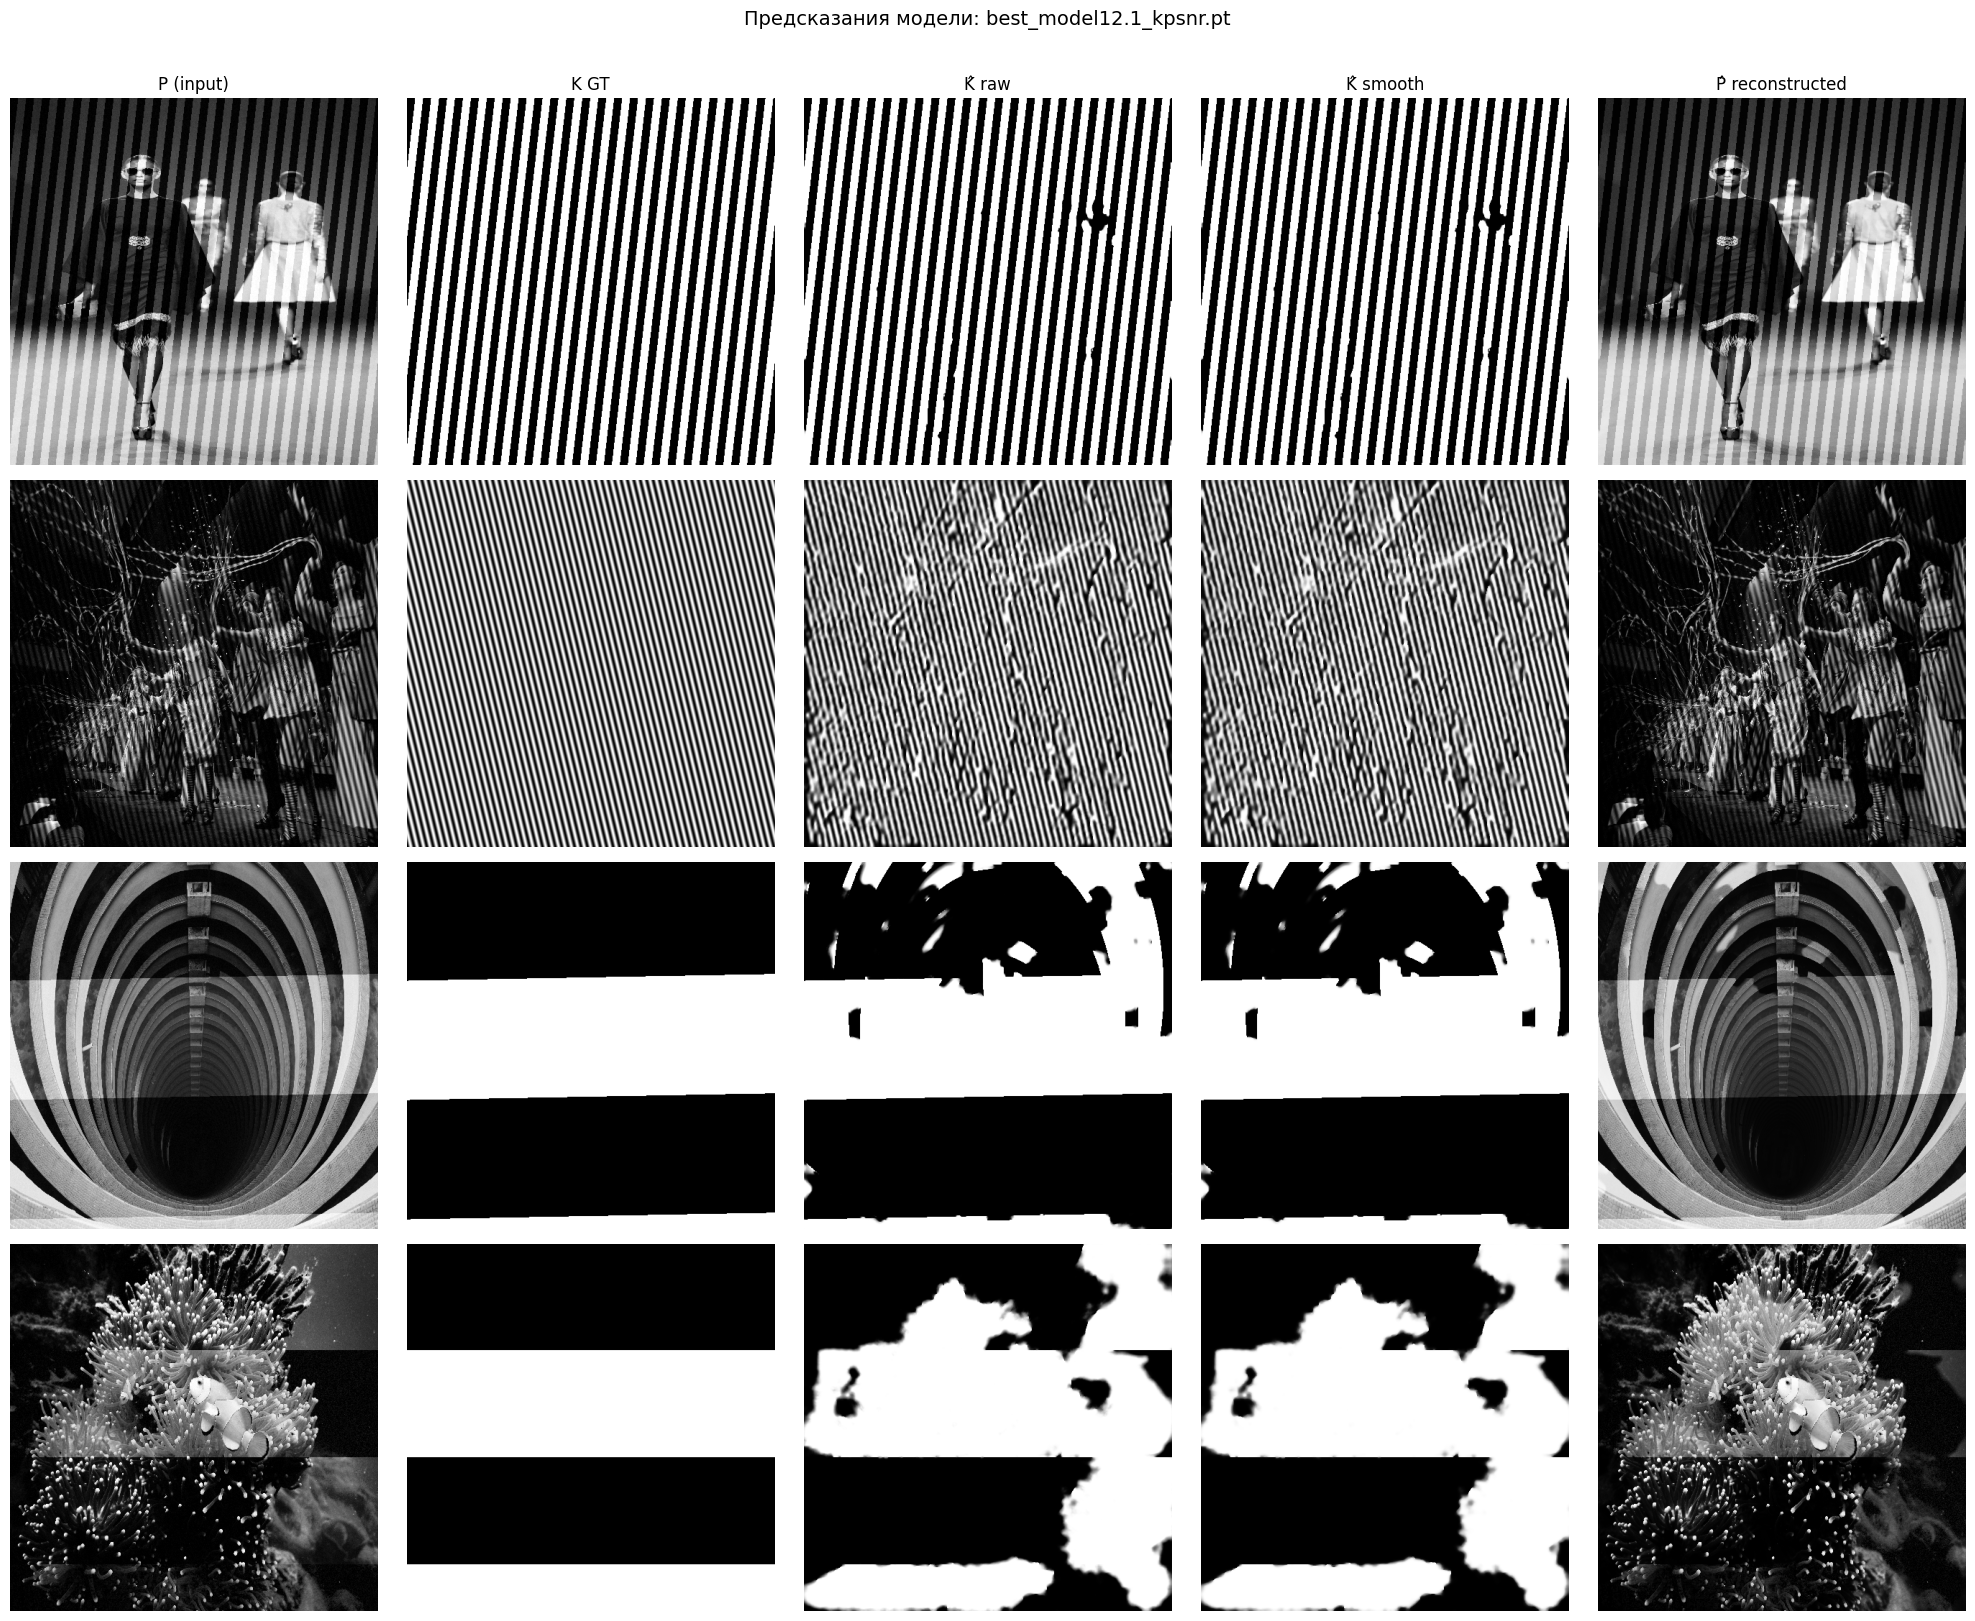

PSNR K (raw) на этих 4 примерах: 14.12 dB
PSNR K (smooth) на этих 4 примерах: 14.07 dB


In [14]:
# ЯЧЕЙКА 9: Загрузка конкретной модели и визуализация

import torch
import matplotlib.pyplot as plt
import cv2
import numpy as np

# ------------------- 1. Выбор файла модели -------------------
# Рекомендую загружать модель с лучшим PSNR K (она даёт более чёткие маски)
MODEL_PATH = "best_model12.1_kpsnr.pt"
# Альтернатива: "best_model_v2_loss.pt" – модель с наименьшим валидационным loss

print(f"Загружаем модель из: {MODEL_PATH}")

# ------------------- 2. Инициализация архитектуры (если raw_model ещё нет) -------------------
# Если после перезапуска ядра переменная raw_model не определена, создадим модель заново.
try:
    raw_model
except NameError:
    print("raw_model не найдена, создаём архитектуру KPredictor...")
    # (Код архитектуры точно такой же, как в ЯЧЕЙКЕ 5)
    class ResBlock(nn.Module):
        def __init__(self, ch, dropout=0.1):
            super().__init__()
            self.net = nn.Sequential(
                nn.Conv2d(ch, ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(ch),
                nn.GELU(),
                nn.Dropout2d(dropout),
                nn.Conv2d(ch, ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(ch),
            )
            self.dropout = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()
        def forward(self, x):
            return F.gelu(x + self.dropout(self.net(x)))

    class DownBlock(nn.Module):
        def __init__(self, in_ch, out_ch, n_res=2, dropout=0.1):
            super().__init__()
            self.conv = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.GELU(),
                *[ResBlock(out_ch, dropout) for _ in range(n_res)],
            )
            self.pool = nn.MaxPool2d(2)
        def forward(self, x):
            x = self.conv(x)
            return self.pool(x), x

    class UpBlock(nn.Module):
        def __init__(self, in_ch, skip_ch, out_ch, n_res=2, dropout=0.1):
            super().__init__()
            self.up = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
            self.conv = nn.Sequential(
                nn.Conv2d(out_ch + skip_ch, out_ch, 3, padding=1, bias=False),
                nn.GroupNorm(min(8, out_ch), out_ch),
                nn.GELU(),
                *[ResBlock(out_ch, dropout) for _ in range(n_res)],
            )
        def forward(self, x, skip):
            x = self.up(x)
            if x.shape[2:] != skip.shape[2:]:
                x = F.interpolate(x, size=skip.shape[2:], mode="bilinear",
                                  align_corners=False)
            return self.conv(torch.cat([x, skip], dim=1))

    class KPredictor(nn.Module):
        def __init__(self, base_ch=32, dropout=0.1):
            super().__init__()
            self.d1 = DownBlock(1,         base_ch,       dropout=dropout)
            self.d2 = DownBlock(base_ch,   base_ch * 2,   dropout=dropout)
            self.d3 = DownBlock(base_ch*2, base_ch * 4,   dropout=dropout)
            self.d4 = DownBlock(base_ch*4, base_ch * 8,   dropout=dropout)
            self.bot = nn.Sequential(ResBlock(base_ch*8, dropout),
                                     ResBlock(base_ch*8, dropout))
            self.u4 = UpBlock(base_ch*8, base_ch*8, base_ch*4, dropout=dropout)
            self.u3 = UpBlock(base_ch*4, base_ch*4, base_ch*2, dropout=dropout)
            self.u2 = UpBlock(base_ch*2, base_ch*2, base_ch,   dropout=dropout)
            self.u1 = UpBlock(base_ch,   base_ch,   base_ch,   dropout=dropout)
            self.head = nn.Sequential(
                nn.Conv2d(base_ch, base_ch // 2, 3, padding=1),
                nn.GELU(),
                nn.Conv2d(base_ch // 2, 1, 1),
            )
        def forward(self, P):
            x, s1 = self.d1(P)
            x, s2 = self.d2(x)
            x, s3 = self.d3(x)
            x, s4 = self.d4(x)
            x = self.bot(x)
            x = self.u4(x, s4)
            x = self.u3(x, s3)
            x = self.u2(x, s2)
            x = self.u1(x, s1)
            return torch.sigmoid(self.head(x))

    raw_model = KPredictor(base_ch=32, dropout=0.1)

# Переносим модель на нужное устройство
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
raw_model = raw_model.to(device)

# ------------------- 3. Загрузка весов -------------------
state_dict = torch.load(MODEL_PATH, map_location=device)
raw_model.load_state_dict(state_dict)
raw_model.eval()
print("Модель загружена и готова к инференсу.")

# ------------------- 4. Функция reconstruction_loss (если не определена) -------------------
try:
    reconstruction_loss
except NameError:
    def reconstruction_loss(K_hat, R, G, P):
        dev = K_hat.device
        R = R.to(dev)
        G = G.to(dev)
        P = P.to(dev)
        eps = 1e-6
        R_pow = torch.pow(R.clamp(eps, 1.0), 0.7)
        G_sq = G ** 2
        P_hat = K_hat * R_pow + (1 - K_hat) * G_sq
        return F.mse_loss(P_hat, P), P_hat

# ------------------- 5. Визуализация -------------------
# Убедимся, что val_dl доступен (если нет – создадим)
try:
    val_dl
except NameError:
    from torch.utils.data import DataLoader
    val_ds = StripeDataset(val_paths, ALL_CONFIGS, augment=False)
    val_dl = DataLoader(val_ds, batch_size=4, shuffle=False, num_workers=2, pin_memory=True)

batch = next(iter(val_dl))
N_SHOW = 4

P_t    = batch["P"][:N_SHOW].to(device)
R_t    = batch["R"][:N_SHOW].to(device)
G_t    = batch["G"][:N_SHOW].to(device)
K_gt_t = batch["K"][:N_SHOW].to(device)

with torch.no_grad():
    K_hat_t = raw_model(P_t)
    _, P_hat_t = reconstruction_loss(K_hat_t, R_t, G_t, P_t)

P_np     = P_t.cpu().numpy()[:, 0]
K_gt_np  = K_gt_t.cpu().numpy()[:, 0]
K_hat_np = K_hat_t.cpu().numpy()[:, 0]
P_hat_np = P_hat_t.cpu().numpy()[:, 0].clip(0, 1)

# Сглаживание предсказанной маски (опционально)
K_hat_smooth_np = np.array([cv2.bilateralFilter(k, d=5, sigmaColor=0.1, sigmaSpace=5)
                            for k in K_hat_np])

fig, axes = plt.subplots(N_SHOW, 5, figsize=(20, 4 * N_SHOW))
titles = ["P (input)", "K GT", "K̂ raw", "K̂ smooth", "P̂ reconstructed"]

for i in range(N_SHOW):
    imgs = [P_np[i], K_gt_np[i], K_hat_np[i], K_hat_smooth_np[i], P_hat_np[i]]
    for j, (img, ttl) in enumerate(zip(imgs, titles)):
        ax = axes[i, j]
        ax.imshow(img, cmap="gray", vmin=0, vmax=1)
        if i == 0:
            ax.set_title(ttl, fontsize=12)
        ax.axis("off")

plt.suptitle(f"Предсказания модели: {MODEL_PATH}", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Дополнительно: посчитаем PSNR по K для этого батча
from skimage.metrics import peak_signal_noise_ratio
psnr_k_raw = np.mean([peak_signal_noise_ratio(K_gt_np[i], K_hat_np[i], data_range=1.0) for i in range(N_SHOW)])
psnr_k_smooth = np.mean([peak_signal_noise_ratio(K_gt_np[i], K_hat_smooth_np[i], data_range=1.0) for i in range(N_SHOW)])
print(f"PSNR K (raw) на этих {N_SHOW} примерах: {psnr_k_raw:.2f} dB")
print(f"PSNR K (smooth) на этих {N_SHOW} примерах: {psnr_k_smooth:.2f} dB")

Форма загруженных данных: (131, 131)
Тип данных: float64
Диапазон значений: [0.162, 0.797]
Ресайз до 512x512
Тензор для модели: torch.Size([1, 1, 512, 512])


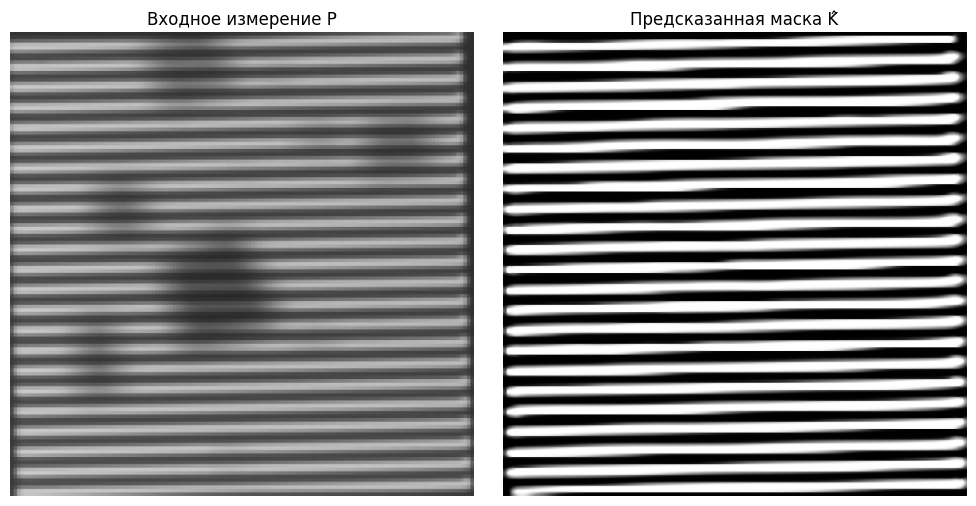

In [15]:
data = np.load("lf.npy")          # загружаем
print(f"Форма загруженных данных: {data.shape}")
print(f"Тип данных: {data.dtype}")
print(f"Диапазон значений: [{data.min():.3f}, {data.max():.3f}]")

# Если массив 3D, например (H, W, C) или (C, H, W) — приводим к (H, W)
if data.ndim == 3:
    if data.shape[0] in [1, 3]:        # предположим (C, H, W)
        data = data.transpose(1, 2, 0)
    # берём первый канал, если их несколько
    if data.shape[2] > 1:
        data = data[:, :, 0]
        print("Используем первый канал как P")
elif data.ndim == 2:
    pass   # уже (H, W)
else:
    raise ValueError(f"Неожиданная размерность: {data.ndim}")

H, W = data.shape[:2]
if (H, W) != (IMG_SIZE, IMG_SIZE):
    data = cv2.resize(data, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
    print(f"Ресайз до {IMG_SIZE}x{IMG_SIZE}")

# Нормализация, если значения вне [0,1]
if data.max() > 1.0:
    data = data / 255.0
    print("Нормализация /255")

# Добавляем размерности: (H,W) -> (1,1,H,W) для батча и канала
P_tensor = torch.from_numpy(data).float().unsqueeze(0).unsqueeze(0).to("cuda:0")
print(f"Тензор для модели: {P_tensor.shape}")


raw_model = raw_model.to("cuda:0")   # модель уже загружена из предыдущей ячейки
raw_model.eval()
with torch.no_grad():
    K_hat_tensor = raw_model(P_tensor)          # (1,1,512,512)
    K_hat = K_hat_tensor.squeeze().cpu().numpy() # (512,512)

# ------------------------------------------------------------
# 4. Визуализация
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(data, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Входное измерение P")
axes[0].axis("off")

axes[1].imshow(K_hat, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Предсказанная маска K̂")
axes[1].axis("off")

plt.tight_layout()
plt.savefig("K_lf.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
IMG_SIZE = 512
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------------------
# Загрузка и подготовка данных
# ------------------------------------------------------------
data = np.load("lf.npy")
if data.ndim == 3:
    if data.shape[0] in [1, 3]:
        data = data.transpose(1, 2, 0)
    if data.shape[2] > 1:
        data = data[:, :, 0]
if data.ndim != 2:
    raise ValueError(f"Неожиданная размерность: {data.ndim}")

H, W = data.shape
if (H, W) != (IMG_SIZE, IMG_SIZE):
    data = cv2.resize(data, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
if data.max() > 1.0:
    data = data / 255.0

P_tensor = torch.from_numpy(data).float().unsqueeze(0).unsqueeze(0).to(DEVICE)

# ------------------------------------------------------------
# Модель (должна быть загружена ранее, raw_model)
# ------------------------------------------------------------
raw_model = raw_model.to(DEVICE)
raw_model.eval()

with torch.no_grad():
    K_hat_tensor = raw_model(P_tensor)          # (1,1,512,512)
    K_hat = K_hat_tensor.squeeze().cpu().numpy() # (512,512)

# Сохраняем только предсказанную маску как изображение
K_hat_uint8 = (K_hat * 255).astype(np.uint8)
cv2.imwrite("K_lf.png", K_hat_uint8)
print("Сохранено: K_hat.png")

Сохранено: K_hat.png
